In [1]:
# mount google drive and set up paths
from google.colab import drive
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive')

Mounted at /content/drive


In [2]:
from rich.traceback import install
install()

import os
from pathlib import Path
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import cv2
import subprocess
import tempfile

from setup_helper import download_repos_and_setup, SAM_REPO, SAM_CHECKPOINT, LIGHTGLUE_REPO, SWINIR_REPO, SWINIR_MODEL, INPUT_DIR, show_anns, show_image, show_mask_over_image, plot_masks, plot_one_mask, swinir_upscale 

In [3]:
download_repos_and_setup() # run just once 

SAM repo found on Drive, skipping clone.
SAM checkpoint found on Drive, skipping download.
LightGlue found on Drive, skipping clone.
SwinIR repo found on Drive, skipping clone.
SwinIR model found on Drive, skipping download.


In [4]:
from lightglue import LightGlue, SuperPoint, DISK
from lightglue.utils import load_image, rbd
from lightglue import viz2d
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

device = 'cuda' if torch.cuda.is_available() else 'cpu'
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT)
_ = sam.to(device=device)

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [128]:
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=16,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    # crop_n_layers=1,
    # crop_n_points_downscale_factor=2,
    # min_mask_region_area=100
)

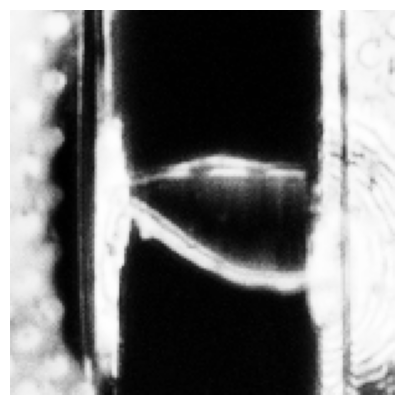

In [100]:
img_flm = show_image(INPUT_DIR / 'flm_center_crop.png') # show image actually returns image and also plots it

In [101]:
img_flm = swinir_upscale(img_flm)

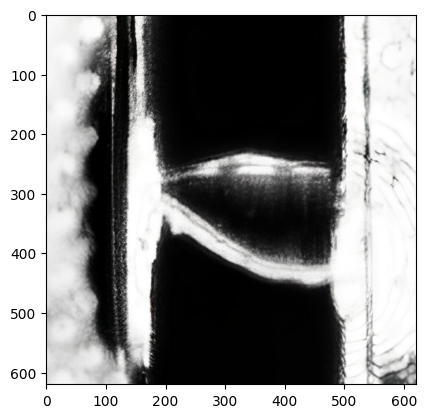

In [126]:
plt.imshow(img_flm)

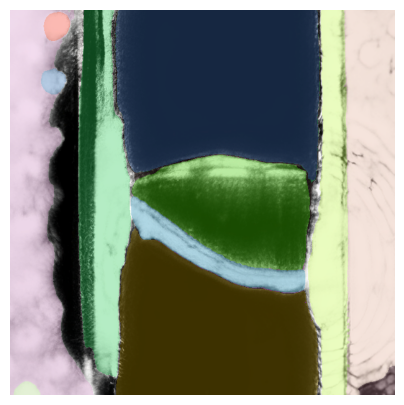

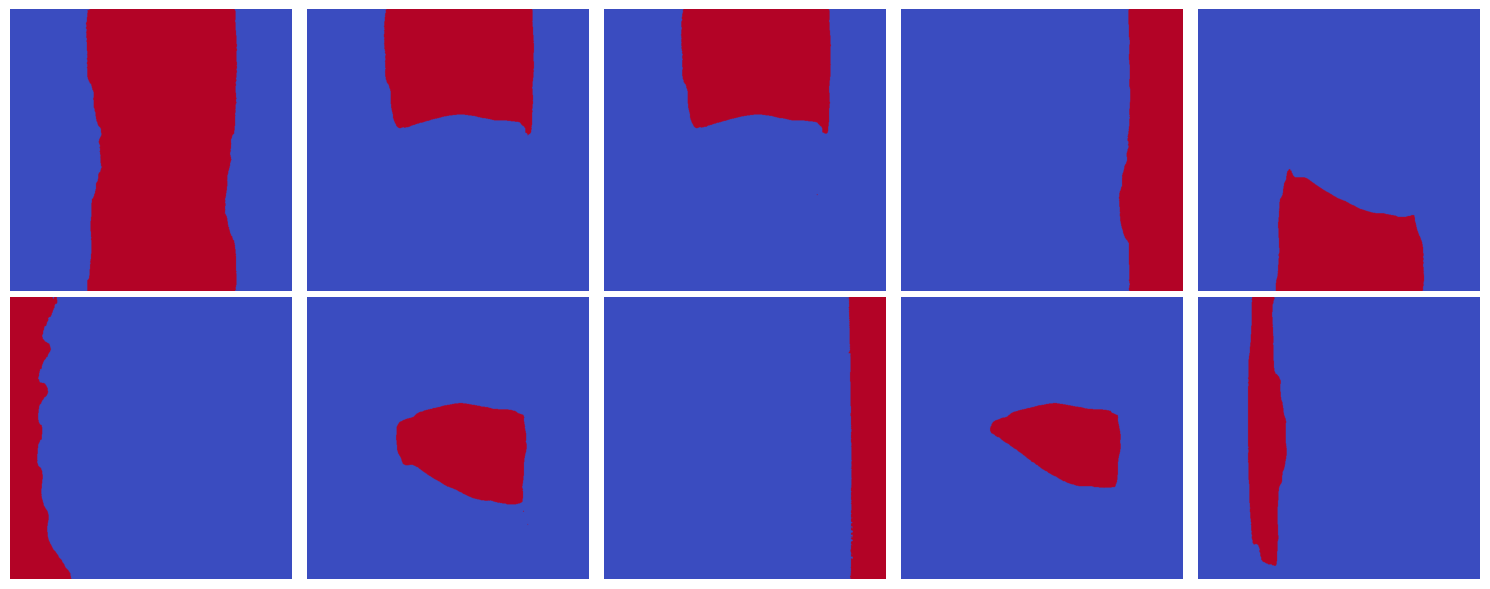

In [129]:
mask_flm = mask_generator.generate(img_flm)
show_mask_over_image(mask_flm, img_flm)

# arrange the masks by the decreasing area
mask_flm = sorted(mask_flm, key=lambda x: -x['area'])

plot_masks(mask_flm, 10)

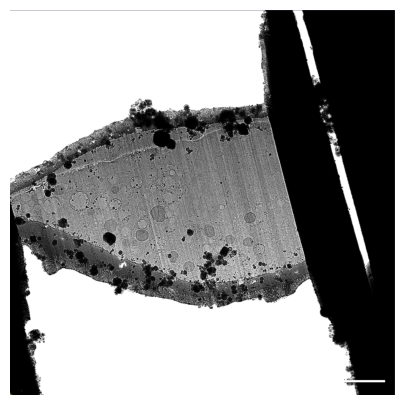

In [106]:
img_tem = show_image(INPUT_DIR / 'tem.png')

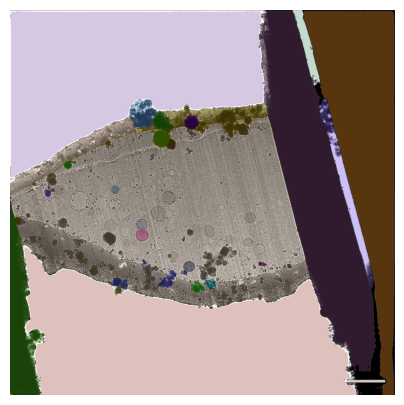

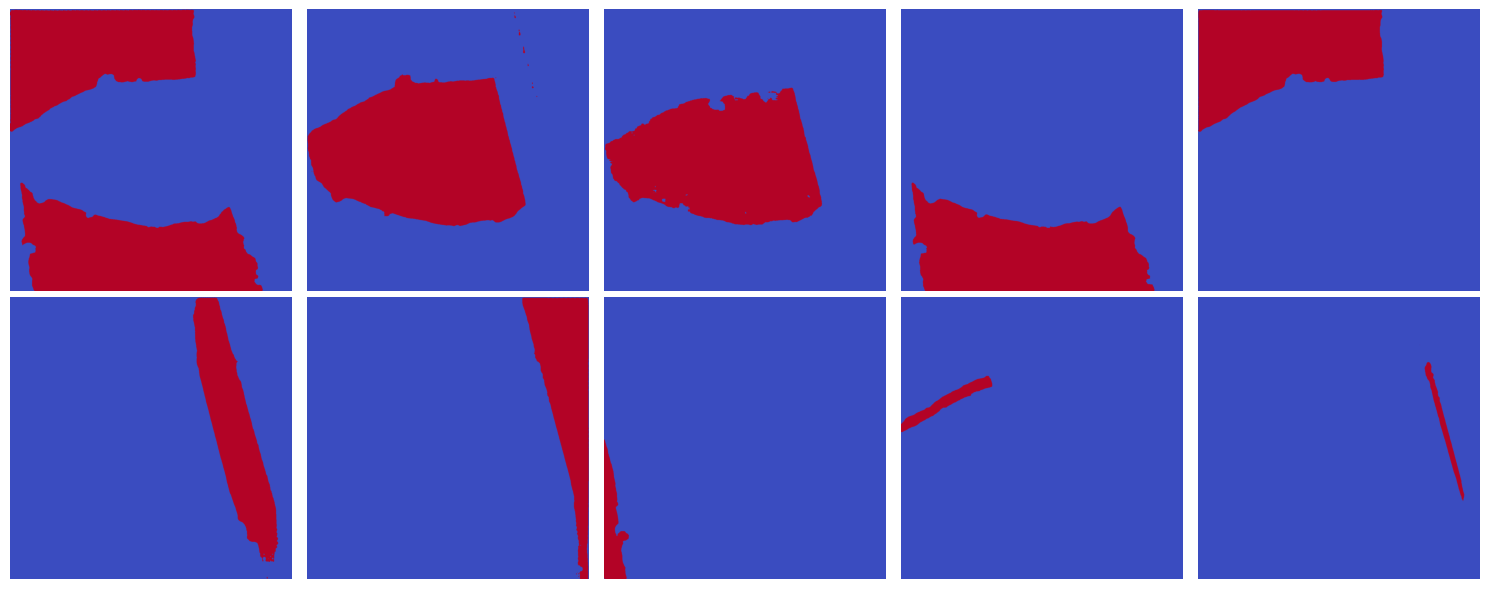

In [130]:
mask_tem = mask_generator.generate(img_tem)
show_mask_over_image(mask_tem, img_tem)

# arrange the masks by the decreasing area
mask_tem = sorted(mask_tem, key=lambda x: -x['area'])

plot_masks(mask_tem, 10)

### Extract the keypoints and match

In [156]:
extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(
    features="superpoint",
    # depth_confidence=-1,   # disable early stopping
    # width_confidence=-1,    # disable pruning
    filter_threshold=0.05, # higher filter threshold allows lesser points; I need to get more keypoints but they should from widely separated regions so that matching is better, therefore I have kept the filter threshold quite low
).eval().to(device)

In [ ]:
def create_tensor_from_mask(mask):
    image = np.stack((mask,) * 3, axis=0)
    return torch.from_numpy(image).to(dtype=torch.float32)

def get_keypoint_matches(image0, image1):
    feats0 = extractor.extract(image0.to(device))
    feats1 = extractor.extract(image1.to(device))
    matches01 = matcher({"image0": feats0, "image1": feats1})
    feats0, feats1, matches01 = [
        rbd(x) for x in [feats0, feats1, matches01]
    ]  # remove batch dimension

    kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
    m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]
    return kpts0, kpts1, m_kpts0, m_kpts1, matches01

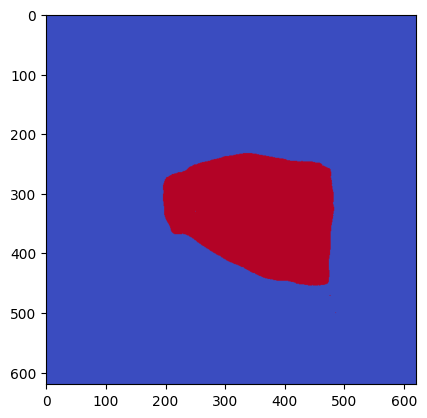

In [108]:
plot_one_mask(mask_flm, 7)

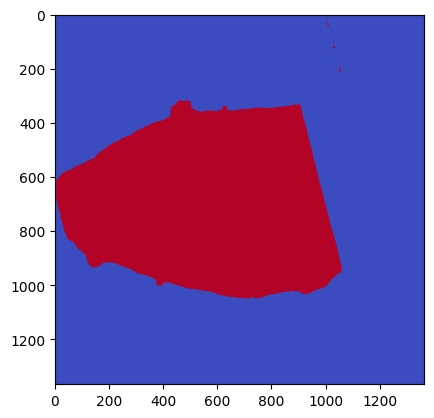

In [110]:
plot_one_mask(mask_tem, 1)

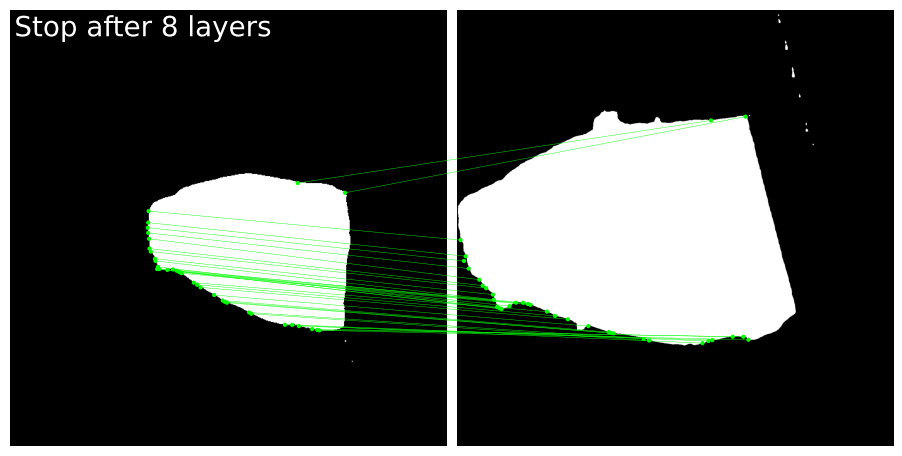

In [157]:
image0 = create_tensor_from_mask(mask_flm[6]['segmentation'])
image1 = create_tensor_from_mask(mask_tem[1]['segmentation'])
kpts0, kpts1, m_kpts0, m_kpts1, matches01 = get_keypoint_matches(image0, image1)
axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.3)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

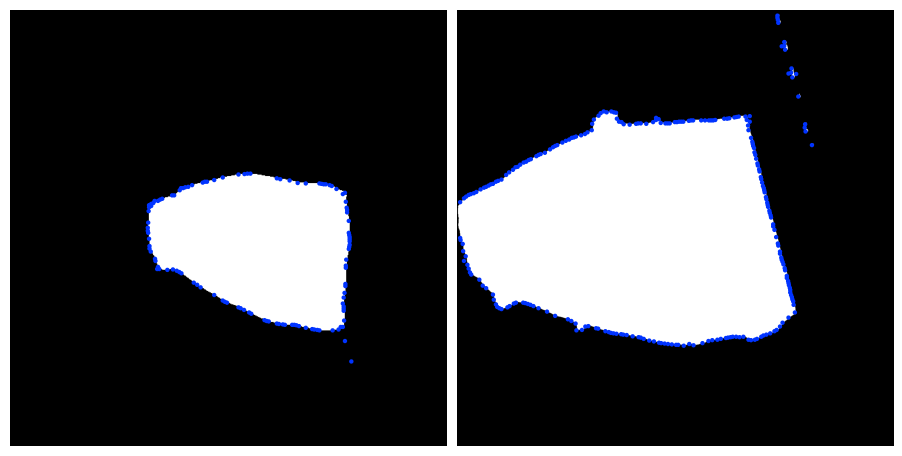

In [147]:
kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

### Rotation matrix from the keypoints

In [158]:
# need to bring the tensor to the cpu first
m_kpts0 = m_kpts0.cpu()
m_kpts1 = m_kpts1.cpu()
transformation_matrix, inliers = cv2.estimateAffinePartial2D(
    m_kpts0.numpy(),
    m_kpts1.numpy()
)

In [159]:
transformation_matrix

array([[ 3.10271665e+00,  7.45691135e-01, -7.88285061e+02],
       [-7.45691135e-01,  3.10271665e+00, -5.13373016e+01]])

In [160]:
h, w = img_tem.shape[:2]

# warp the FLM image using the estimated transform matrix M
warped_flm = cv2.warpAffine(img_flm, transformation_matrix, (w, h))

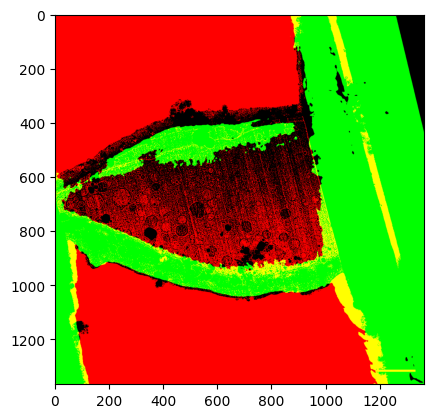

In [161]:
# merge by using otsu threshold
from skimage.filters import threshold_otsu

img_tem_1c = img_tem[:, :, 0]
wrapped_flm_1c = warped_flm[:, :, 0]
tem_thresh = threshold_otsu(img_tem_1c)
flm_thresh = threshold_otsu(wrapped_flm_1c)

tem_binary = (img_tem_1c > tem_thresh).astype(np.uint8) * 255
flm_binary = (wrapped_flm_1c > flm_thresh).astype(np.uint8) * 255

overlay_rgb = np.zeros((h, w, 3), dtype=np.uint8)
overlay_rgb[:, :, 0] = tem_binary
overlay_rgb[:, :, 1] = flm_binary

plt.imshow(overlay_rgb)
plt.show()

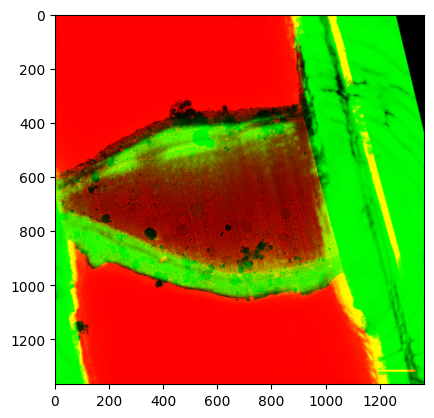

In [163]:
h, w = img_tem.shape[:2]

# warp the FLM image using the estimated transform matrix M
warped_flm = cv2.warpAffine(img_flm, transformation_matrix, (w, h))

# overlay by blending the two images
overlay = cv2.addWeighted(img_tem, 0.5, warped_flm, 0.5, 0)

# create an RGB image where TEM is in one channel and FLM in another
overlay_rgb = np.zeros((h, w, 3), dtype=np.uint8)
overlay_rgb[:, :, 0] = img_tem[:, :, 0]      # TEM in red channel
overlay_rgb[:, :, 1] = warped_flm[:, :, 0]     # FLM in green channel

plt.imshow(overlay_rgb)
plt.show()

### Area of interest from flm based on region of activity highlighted by fluoroscense